In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df= pd.read_csv('gym_churn_prediction_dirty_dataset.csv')
df.head()

,Member_ID,Name,Age,Gender,Membership_Type,Membership_Duration_Months,Attendance_Frequency_Per_Week,Last_Checkin_Days_Ago,Monthly_Fee,Payment_Delay_Count,...,Workout_Sessions_Completed,Personal_Trainer,Group_Class_Participation,BMI,Distance_From_Gym_km,App_Usage_Hours,Renewal_Count,Goal_Type,UPI_Payment_Usage,Churn_Status
0,GYM100000,Rohan Dayal,56.0,Male,Half-Yearly,29,3.0,17,5856.0,7,...,131,Yes,22,16.4,6.5,7.5,4,Bodybuilding,Yes,0
1,GYM100001,Himmat Baral,46.0,??,Quarterly,32,3.0,50,1046.0,2,...,152,Yes,10,30.4,21.2,27.0,1,Fitness,No,1
2,GYM100002,Azad Manne,32.0,Female,Quarterly,16,5.0,45,2903.0,4,...,345,No,6,15.1,22.9,12.4,7,Weight Loss,No,1
3,GYM100003,Jayesh Jayaraman,60.0,Other,Annual,26,6.0,74,2918.0,8,...,333,No,5,25.1,19.2,15.4,3,Weight Loss,Yes,1
4,GYM100004,Azad Date,25.0,Female,Half-Yearly,6,6.0,58,4897.0,8,...,445,Yes,21,24.7,14.4,36.0,6,Bodybuilding,No,0


In [3]:
ds= df.copy()

# 1. Understanding data

In [4]:
ds.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20840 entries, 0 to 20839
Data columns (total 21 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Member_ID                      20840 non-null  object 
 1   Name                           20840 non-null  object 
 2   Age                            19766 non-null  float64
 3   Gender                         20840 non-null  object 
 4   Membership_Type                20840 non-null  object 
 5   Membership_Duration_Months     20840 non-null  int64  
 6   Attendance_Frequency_Per_Week  19774 non-null  float64
 7   Last_Checkin_Days_Ago          20840 non-null  int64  
 8   Monthly_Fee                    19785 non-null  float64
 9   Payment_Delay_Count            20840 non-null  int64  
 10  Customer_Satisfaction_Score    19741 non-null  float64
 11  Workout_Sessions_Completed     20840 non-null  int64  
 12  Personal_Trainer               20840 non-null 

In [5]:
ds.describe()

,Age,Membership_Duration_Months,Attendance_Frequency_Per_Week,Last_Checkin_Days_Ago,Monthly_Fee,Payment_Delay_Count,Customer_Satisfaction_Score,Workout_Sessions_Completed,Group_Class_Participation,BMI,Distance_From_Gym_km,App_Usage_Hours,Renewal_Count,Churn_Status
count,19766.000000,20840.000000,19774.000000,20840.000000,19785.000000,20840.000000,19741.000000,20840.000000,20840.000000,20840.000000,20840.000000,20840.000000,20840.000000,20840.000000
mean,41.791258,30.064203,3.913624,44.466027,5678.797271,4.504990,5.495162,251.000384,14.499904,23.991756,12.756713,20.001641,3.508973,0.450864
std,19.645748,16.929637,5.771192,26.017561,12517.678670,2.875452,2.869950,142.897609,8.690486,4.002944,7.090348,11.555894,2.285580,0.497592
min,-5.000000,1.000000,0.000000,0.000000,500.000000,0.000000,1.000000,1.000000,0.000000,7.900000,0.500000,0.000000,0.000000,0.000000
25%,29.000000,16.000000,1.000000,22.000000,1943.000000,2.000000,3.000000,128.000000,7.000000,21.300000,6.500000,10.100000,2.000000,0.000000
50%,41.000000,30.000000,3.000000,44.000000,3391.000000,4.000000,5.000000,251.000000,15.000000,23.900000,12.800000,20.100000,4.000000,0.000000
75%,53.000000,45.000000,5.000000,67.000000,4812.000000,7.000000,8.000000,374.000000,22.000000,26.700000,18.900000,30.000000,6.000000,1.000000
max,200.000000,59.000000,49.000000,89.000000,99954.000000,9.000000,10.000000,499.000000,29.000000,39.600000,25.000000,40.000000,7.000000,1.000000


In [6]:
ds.columns= ds.columns.str.lower()

In [7]:
ds.head(2)

,member_id,name,age,gender,membership_type,membership_duration_months,attendance_frequency_per_week,last_checkin_days_ago,monthly_fee,payment_delay_count,...,workout_sessions_completed,personal_trainer,group_class_participation,bmi,distance_from_gym_km,app_usage_hours,renewal_count,goal_type,upi_payment_usage,churn_status
0,GYM100000,Rohan Dayal,56.0,Male,Half-Yearly,29,3.0,17,5856.0,7,...,131,Yes,22,16.4,6.5,7.5,4,Bodybuilding,Yes,0
1,GYM100001,Himmat Baral,46.0,??,Quarterly,32,3.0,50,1046.0,2,...,152,Yes,10,30.4,21.2,27.0,1,Fitness,No,1


# 2. Handling Missing Values

In [8]:
ds.isnull().sum()

member_id                           0
name                                0
age                              1074
gender                              0
membership_type                     0
membership_duration_months          0
attendance_frequency_per_week    1066
last_checkin_days_ago               0
monthly_fee                      1055
payment_delay_count                 0
customer_satisfaction_score      1099
workout_sessions_completed          0
personal_trainer                    0
group_class_participation           0
bmi                                 0
distance_from_gym_km                0
app_usage_hours                     0
renewal_count                       0
goal_type                           0
upi_payment_usage                   0
churn_status                        0
dtype: int64

In [ ]:
# Categorical columns
ds['gender'] = ds['gender'].fillna(ds['gender'].mode()[0])
ds['membership_type'] = ds['membership_type'].fillna(ds['membership_type'].mode()[0])
ds['personal_trainer'] = ds['personal_trainer'].fillna(ds['personal_trainer'].mode()[0])
ds['goal_type'] = ds['goal_type'].fillna(ds['goal_type'].mode()[0])
ds['upi_payment_usage'] = ds['upi_payment_usage'].fillna(ds['upi_payment_usage'].mode()[0])

# Numeric columns
ds['age'] = ds['age'].fillna(ds['age'].median())
ds['membership_duration_months'] = ds['membership_duration_months'].fillna(ds['membership_duration_months'].median())
ds['attendance_frequency_per_week'] = ds['attendance_frequency_per_week'].fillna(ds['attendance_frequency_per_week'].median())
ds['last_checkin_days_ago'] = ds['last_checkin_days_ago'].fillna(ds['last_checkin_days_ago'].median())
ds['monthly_fee'] = ds['monthly_fee'].fillna(ds['monthly_fee'].median())
ds['payment_delay_count'] = ds['payment_delay_count'].fillna(ds['payment_delay_count'].median())
ds['workout_sessions_completed'] = ds['workout_sessions_completed'].fillna(ds['workout_sessions_completed'].median())
ds['group_class_participation'] = ds['group_class_participation'].fillna(ds['group_class_participation'].median())
ds['bmi'] = ds['bmi'].fillna(ds['bmi'].median())
ds['distance_from_gym_km'] = ds['distance_from_gym_km'].fillna(ds['distance_from_gym_km'].median())
ds['app_usage_hours'] = ds['app_usage_hours'].fillna(ds['app_usage_hours'].median())
ds['renewal_count'] = ds['renewal_count'].fillna(ds['renewal_count'].median())
ds['churn_status'] = ds['churn_status'].fillna(ds['churn_status'].mode()[0])

# 3. Handling Duplicates

In [10]:
if 'member_id' in ds.columns and 'name' in ds.columns and 'churn_status' in ds.columns:
    ds = ds.drop_duplicates(
        subset=['member_id', 'name', 'churn_status']
    )

elif 'member_id' in ds.columns and 'churn_status' in ds.columns:
    ds = ds.drop_duplicates(
        subset=['member_id', 'churn_status']
    )

else:
    ds = ds.drop_duplicates(
        subset=[
            'age',
            'gender',
            'membership_type',
            'monthly_fee',
            'attendance_frequency_per_week',
            'churn_status'
        ]
    )

ds.head(2)

,member_id,name,age,gender,membership_type,membership_duration_months,attendance_frequency_per_week,last_checkin_days_ago,monthly_fee,payment_delay_count,...,workout_sessions_completed,personal_trainer,group_class_participation,bmi,distance_from_gym_km,app_usage_hours,renewal_count,goal_type,upi_payment_usage,churn_status
0,GYM100000,Rohan Dayal,56.0,Male,Half-Yearly,29,3.0,17,5856.0,7,...,131,Yes,22,16.4,6.5,7.5,4,Bodybuilding,Yes,0
1,GYM100001,Himmat Baral,46.0,??,Quarterly,32,3.0,50,1046.0,2,...,152,Yes,10,30.4,21.2,27.0,1,Fitness,No,1


In [11]:
ds['gender'].unique()

array(['Male', '??', 'Female', 'Other', 'mAle', 'unknown', 'FEMALE'],
      dtype=object)

# 4. Remove Extra

In [12]:
ds.columns

Index(['member_id', 'name', 'age', 'gender', 'membership_type',
       'membership_duration_months', 'attendance_frequency_per_week',
       'last_checkin_days_ago', 'monthly_fee', 'payment_delay_count',
       'customer_satisfaction_score', 'workout_sessions_completed',
       'personal_trainer', 'group_class_participation', 'bmi',
       'distance_from_gym_km', 'app_usage_hours', 'renewal_count', 'goal_type',
       'upi_payment_usage', 'churn_status'],
      dtype='object')

In [13]:
cols = [
    'age',
    'gender',
    'membership_type',
    'membership_duration_months',
    'attendance_frequency_per_week',
    'last_checkin_days_ago',
    'monthly_fee',
    'payment_delay_count',
    'workout_sessions_completed',
    'personal_trainer',
    'group_class_participation',
    'bmi',
    'distance_from_gym_km',
    'app_usage_hours',
    'renewal_count',
    'goal_type',
    'upi_payment_usage',
    'churn_status'
]

ds = ds[cols]

ds.head(2)

,age,gender,membership_type,membership_duration_months,attendance_frequency_per_week,last_checkin_days_ago,monthly_fee,payment_delay_count,workout_sessions_completed,personal_trainer,group_class_participation,bmi,distance_from_gym_km,app_usage_hours,renewal_count,goal_type,upi_payment_usage,churn_status
0,56.0,Male,Half-Yearly,29,3.0,17,5856.0,7,131,Yes,22,16.4,6.5,7.5,4,Bodybuilding,Yes,0
1,46.0,??,Quarterly,32,3.0,50,1046.0,2,152,Yes,10,30.4,21.2,27.0,1,Fitness,No,1


# 4. Extracting Features

In [14]:
ds['churn_status'].unique()

array([0, 1])

In [15]:
ds["churn_status"] = ds["churn_status"].replace(
    {"Yes": 1, "No": 0, "Y": 1, "N": 0, "yes": 1, "no": 0, "y": 1, "n": 0, '  Yes ': 1, '  No ': 0}
).astype(int)

In [16]:
ds['churn_status'].value_counts()

churn_status
0    10988
1     9012
Name: count, dtype: int64

In [17]:
ds.head(3)

,age,gender,membership_type,membership_duration_months,attendance_frequency_per_week,last_checkin_days_ago,monthly_fee,payment_delay_count,workout_sessions_completed,personal_trainer,group_class_participation,bmi,distance_from_gym_km,app_usage_hours,renewal_count,goal_type,upi_payment_usage,churn_status
0,56.0,Male,Half-Yearly,29,3.0,17,5856.0,7,131,Yes,22,16.4,6.5,7.5,4,Bodybuilding,Yes,0
1,46.0,??,Quarterly,32,3.0,50,1046.0,2,152,Yes,10,30.4,21.2,27.0,1,Fitness,No,1
2,32.0,Female,Quarterly,16,5.0,45,2903.0,4,345,No,6,15.1,22.9,12.4,7,Weight Loss,No,1


In [18]:
# str.lower() necessary
ds["personal_trainer"] = (ds['personal_trainer'].str.strip().str.lower().map(
    {"Yes": 1, "No": 0, "Y": 1, "N": 0, "yes": 1, "no": 0, "y": 1, "n": 0}
).astype(int))

In [19]:
# str.lower() necessary
ds["upi_payment_usage"] = (ds['upi_payment_usage'].str.strip().str.lower().map(
    {"Yes": 1, "No": 0, "Y": 1, "N": 0, "yes": 1, "no": 0, "y": 1, "n": 0}
).astype(int))

In [20]:
ds.head()

,age,gender,membership_type,membership_duration_months,attendance_frequency_per_week,last_checkin_days_ago,monthly_fee,payment_delay_count,workout_sessions_completed,personal_trainer,group_class_participation,bmi,distance_from_gym_km,app_usage_hours,renewal_count,goal_type,upi_payment_usage,churn_status
0,56.0,Male,Half-Yearly,29,3.0,17,5856.0,7,131,1,22,16.4,6.5,7.5,4,Bodybuilding,1,0
1,46.0,??,Quarterly,32,3.0,50,1046.0,2,152,1,10,30.4,21.2,27.0,1,Fitness,0,1
2,32.0,Female,Quarterly,16,5.0,45,2903.0,4,345,0,6,15.1,22.9,12.4,7,Weight Loss,0,1
3,60.0,Other,Annual,26,6.0,74,2918.0,8,333,0,5,25.1,19.2,15.4,3,Weight Loss,1,1
4,25.0,Female,Half-Yearly,6,6.0,58,4897.0,8,445,1,21,24.7,14.4,36.0,6,Bodybuilding,0,0


# 5. Encoding

In [21]:
print(ds['gender'].unique())
print(ds['membership_type'].unique())
print(ds['goal_type'].unique())

ds['gender'].str.strip()
ds['membership_type'].str.strip()
ds['goal_type'].str.strip()

['Male' '??' 'Female' 'Other' 'mAle' 'unknown' 'FEMALE']
['Half-Yearly' 'Quarterly' 'Annual' 'Monthly' 'Premium']
['Bodybuilding' 'Fitness' 'Weight Loss' 'Muscle Gain' 'Athletic Training']


0        Bodybuilding
1             Fitness
2         Weight Loss
3         Weight Loss
4        Bodybuilding
             ...     
19995         Fitness
19996     Muscle Gain
19997    Bodybuilding
19998         Fitness
19999    Bodybuilding
Name: goal_type, Length: 20000, dtype: object

In [22]:
enc = pd.get_dummies(
    data=ds,
    columns=[
        'gender',
        'membership_type',
        'goal_type'
    ],
    drop_first=True,
    dtype=int
)

ds = enc

ds.head(2)

,age,membership_duration_months,attendance_frequency_per_week,last_checkin_days_ago,monthly_fee,payment_delay_count,workout_sessions_completed,personal_trainer,group_class_participation,bmi,...,gender_mAle,gender_unknown,membership_type_Half-Yearly,membership_type_Monthly,membership_type_Premium,membership_type_Quarterly,goal_type_Bodybuilding,goal_type_Fitness,goal_type_Muscle Gain,goal_type_Weight Loss
0,56.0,29,3.0,17,5856.0,7,131,1,22,16.4,...,0,0,1,0,0,0,1,0,0,0
1,46.0,32,3.0,50,1046.0,2,152,1,10,30.4,...,0,0,0,0,0,1,0,1,0,0


# 6. Train Test Split

In [23]:
X= ds.drop(columns=['churn_status'])
# y= ds[['churn']]
y= ds['churn_status']

In [24]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test= train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [25]:
X_train.shape, X_test.shape

((16000, 28), (4000, 28))

In [26]:
y_train.shape, y_test.shape

((16000,), (4000,))

# 7. Outlier remove

In [27]:
ds.head()

,age,membership_duration_months,attendance_frequency_per_week,last_checkin_days_ago,monthly_fee,payment_delay_count,workout_sessions_completed,personal_trainer,group_class_participation,bmi,...,gender_mAle,gender_unknown,membership_type_Half-Yearly,membership_type_Monthly,membership_type_Premium,membership_type_Quarterly,goal_type_Bodybuilding,goal_type_Fitness,goal_type_Muscle Gain,goal_type_Weight Loss
0,56.0,29,3.0,17,5856.0,7,131,1,22,16.4,...,0,0,1,0,0,0,1,0,0,0
1,46.0,32,3.0,50,1046.0,2,152,1,10,30.4,...,0,0,0,0,0,1,0,1,0,0
2,32.0,16,5.0,45,2903.0,4,345,0,6,15.1,...,0,0,0,0,0,1,0,0,0,1
3,60.0,26,6.0,74,2918.0,8,333,0,5,25.1,...,0,0,0,0,0,0,0,0,0,1
4,25.0,6,6.0,58,4897.0,8,445,1,21,24.7,...,0,0,1,0,0,0,1,0,0,0


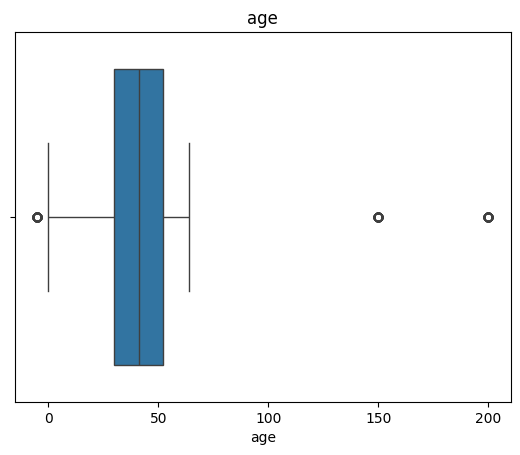

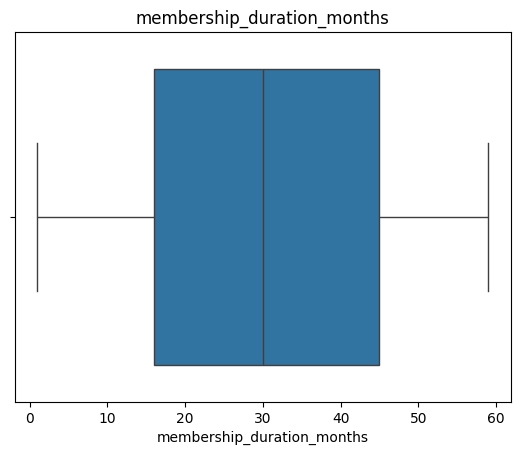

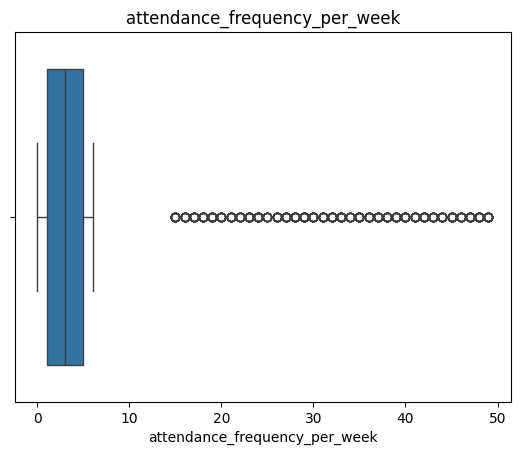

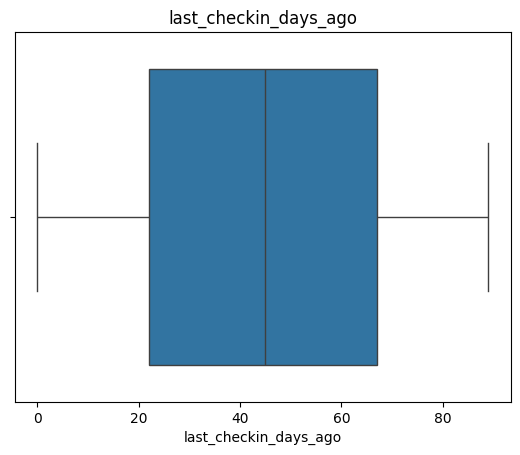

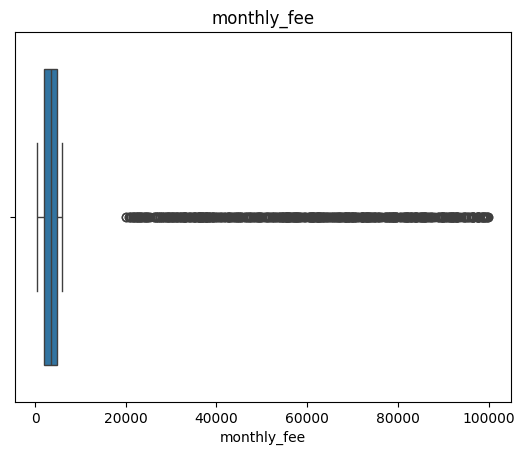

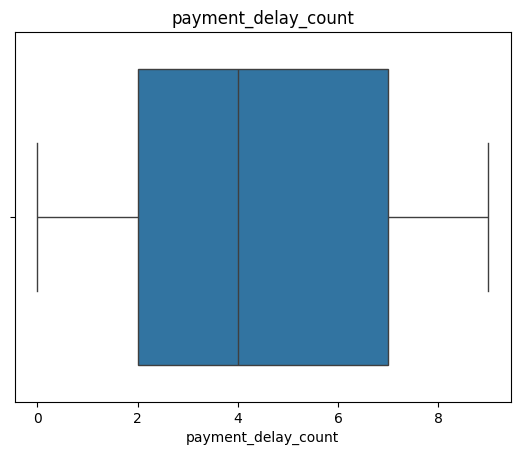

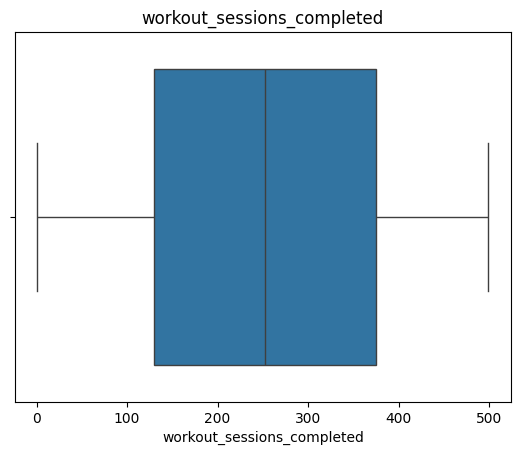

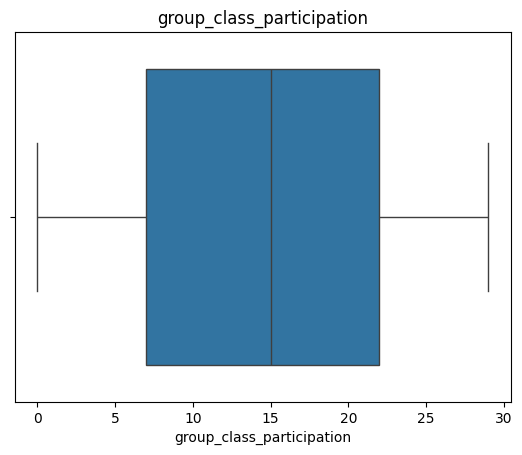

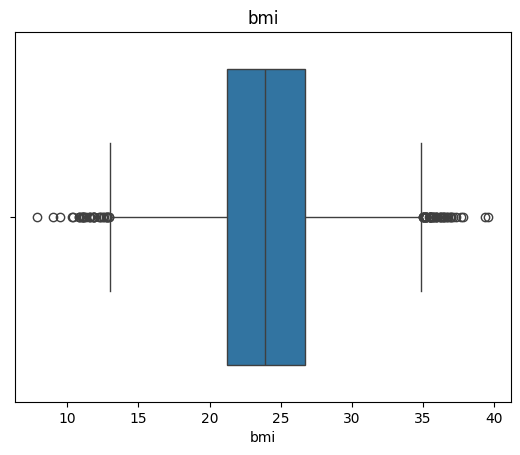

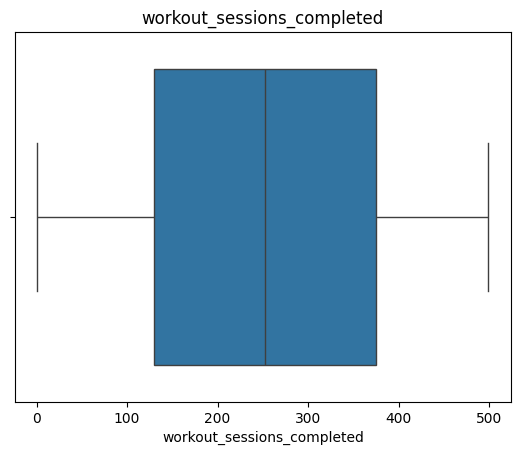

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

for col in ['age', 'membership_duration_months', 'attendance_frequency_per_week', 'last_checkin_days_ago', 'monthly_fee', 'payment_delay_count', 'workout_sessions_completed', 'group_class_participation', 'bmi', 'workout_sessions_completed']:
    sns.boxplot(x=X_train[col])
    plt.title(col)
    plt.show()

In [29]:
def handle_outliers(ds, cols):
    for col in cols:
        Q1 = ds[col].quantile(0.25)
        Q3 = ds[col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        # clip values
        ds[col] = ds[col].clip(lower, upper)

    return ds

In [30]:
num_cols = ['age', 'membership_duration_months', 'attendance_frequency_per_week', 'last_checkin_days_ago', 'monthly_fee', 'payment_delay_count', 'workout_sessions_completed', 'group_class_participation', 'bmi', 'workout_sessions_completed']

X_train = handle_outliers(X_train, num_cols)

# 8. Scaling data

In [31]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train) # converted into array
X_test = scaler.transform(X_test)

# 9. Model Training

In [32]:
print(pd.DataFrame(X_train).isnull().sum())

0     0
1     0
2     0
3     0
4     0
5     0
6     0
7     0
8     0
9     0
10    0
11    0
12    0
13    0
14    0
15    0
16    0
17    0
18    0
19    0
20    0
21    0
22    0
23    0
24    0
25    0
26    0
27    0
dtype: int64


In [33]:
X_train = pd.DataFrame(X_train, columns=X.columns)

In [34]:
from sklearn.ensemble import RandomForestClassifier
model_rf  = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features='sqrt',
    random_state=42
)
model_rf .fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(

In [35]:
from sklearn.svm import LinearSVC

# Faster SVM for large datasets
model_svm = LinearSVC(
    C=1,
    random_state=42,
    max_iter=5000
)

model_svm.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`intercept_scaling`. This scaling allows the intercept term to have adifferent regularization behavior compared to the other features.",1
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: int, default=0Enable verbose output. Note that this setting takes advantage of aper-process runtime setting in liblinear that, if enabled, may not workproperly in a multithreaded context.",0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random

In [36]:
model_svm.score(X_train, y_train)

0.64075

In [37]:
model_svm.score(X_test, y_test)

C:\Users\Chaitanya Gaikwad\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearSVC was fitted with feature names
  warnings.warn(


0.632

In [38]:
model_rf.score(X_train, y_train)

0.7556875

In [39]:
model_rf.score(X_test, y_test)

C:\Users\Chaitanya Gaikwad\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


0.68025

In [40]:
from xgboost import XGBClassifier
model_xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)
model_xgb.fit(X_train, y_train)

C:\Users\Chaitanya Gaikwad\AppData\Roaming\Python\Python313\site-packages\xgboost\training.py:199: UserWarning: [19:36:46] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [41]:
model_xgb.score(X_train, y_train)

0.7810625

In [42]:
model_xgb.score(X_test, y_test)

0.6765

In [43]:
# =========================================
# Compare Gym Models & Select Best Model
# =========================================

models = {
    "SVM": model_svm,
    "Random Forest": model_rf,
    "XGBoost": model_xgb
}

best_model_name = None
best_model = None
best_score = 0

print("\n===== GYM MODEL COMPARISON =====\n")

for name, model in models.items():

    train_score = model.score(X_train, y_train)
    test_score = model.score(X_test, y_test)

    print(f"{name}")
    print(f"Training Accuracy : {train_score:.4f}")
    print(f"Testing Accuracy  : {test_score:.4f}")
    print("-" * 35)

    # Select Model With Highest Test Accuracy
    if test_score > best_score:
        best_score = test_score
        best_model_name = name
        best_model = model

# =========================================
# Final Best Model
# =========================================

print(f"\nBest Model Selected : {best_model_name}")
print(f"Best Accuracy : {best_score:.4f}")


===== GYM MODEL COMPARISON =====

SVM
Training Accuracy : 0.6408
Testing Accuracy  : 0.6320
-----------------------------------


C:\Users\Chaitanya Gaikwad\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearSVC was fitted with feature names
  warnings.warn(
C:\Users\Chaitanya Gaikwad\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


Random Forest
Training Accuracy : 0.7557
Testing Accuracy  : 0.6803
-----------------------------------
XGBoost
Training Accuracy : 0.7811
Testing Accuracy  : 0.6765
-----------------------------------

Best Model Selected : Random Forest
Best Accuracy : 0.6803


In [48]:
new_customer = pd.DataFrame(0, index=[0], columns=X.columns)

In [49]:
new_customer['age'] = 28
new_customer['membership_duration_months'] = 12
new_customer['attendance_frequency_per_week'] = 5
new_customer['last_checkin_days_ago'] = 2
new_customer['monthly_fee'] = 2500
new_customer['payment_delay_count'] = 1
new_customer['workout_sessions_completed'] = 180
new_customer['personal_trainer'] = 1
new_customer['group_class_participation'] = 15
new_customer['bmi'] = 24.5
new_customer['distance_from_gym_km'] = 4.2
new_customer['app_usage_hours'] = 18
new_customer['renewal_count'] = 3
new_customer['upi_payment_usage'] = 1

In [50]:
new_customer['gender_Male'] = 1

new_customer['membership_type_Monthly'] = 1

new_customer['goal_type_Fitness'] = 1

In [51]:
new_customer_scaled = scaler.transform(new_customer)

In [52]:
new_customer_scaled = pd.DataFrame(
    new_customer_scaled,
    columns=X.columns
)

In [53]:
prediction = best_model.predict(new_customer_scaled)

print(f"\nBest Model Selected : {best_model_name}")
print(f"Best Accuracy       : {best_score:.4f}")

if prediction[0] == 1:
    print("\nPrediction : Customer will leave gym")
else:
    print("\nPrediction : Customer will stay in gym")


Best Model Selected : Random Forest
Best Accuracy       : 0.6803

Prediction : Customer will stay in gym


In [54]:
prob = best_model.predict_proba(new_customer_scaled)

stay_prob = prob[0][0] * 100
leave_prob = prob[0][1] * 100

print(f"\nStay Probability  : {stay_prob:.2f}%")
print(f"Leave Probability : {leave_prob:.2f}%")


Stay Probability  : 85.60%
Leave Probability : 14.40%


In [55]:
# =========================================
# Hyperparameter Tuning For Gym Churn
# Using XGBoost
# =========================================

from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV

# =========================================
# XGBoost Parameter Grid
# =========================================

xgb_params = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0]
}

# =========================================
# Base XGBoost Model
# =========================================

xgb = XGBClassifier(
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

# =========================================
# Randomized Search CV
# =========================================

random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=xgb_params,
    n_iter=10,
    cv=3,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1,
    verbose=2
)

# =========================================
# Train Tuned Model
# =========================================

random_search.fit(X_train, y_train)

# =========================================
# Best Parameters
# =========================================

print("\nBest Parameters:\n")
print(random_search.best_params_)

# =========================================
# Best Tuned XGBoost Model
# =========================================

best_xgb = random_search.best_estimator_

# =========================================
# Accuracy Scores
# =========================================

train_score = best_xgb.score(X_train, y_train)
test_score = best_xgb.score(X_test, y_test)

print("\nTraining Accuracy :", train_score)
print("Testing Accuracy  :", test_score)

# =========================================
# New Gym Customer Data
# =========================================

new_customer = pd.DataFrame(0, index=[0], columns=X.columns)

# Numeric Features
new_customer['age'] = 28
new_customer['membership_duration_months'] = 12
new_customer['attendance_frequency_per_week'] = 5
new_customer['last_checkin_days_ago'] = 2
new_customer['monthly_fee'] = 2500
new_customer['payment_delay_count'] = 1
new_customer['workout_sessions_completed'] = 180
new_customer['personal_trainer'] = 1
new_customer['group_class_participation'] = 15
new_customer['bmi'] = 24.5
new_customer['distance_from_gym_km'] = 4.2
new_customer['app_usage_hours'] = 18
new_customer['renewal_count'] = 3
new_customer['upi_payment_usage'] = 1

# Encoded Features
new_customer['gender_Male'] = 1
new_customer['membership_type_Monthly'] = 1
new_customer['goal_type_Fitness'] = 1

# =========================================
# Scale Data
# =========================================

new_customer_scaled = scaler.transform(new_customer)

# Convert Back To DataFrame
new_customer_scaled = pd.DataFrame(
    new_customer_scaled,
    columns=X.columns
)

# =========================================
# Prediction Using Tuned XGBoost
# =========================================

prediction = best_xgb.predict(new_customer_scaled)

if prediction[0] == 1:
    print("\nCustomer will leave gym")
else:
    print("\nCustomer will stay in gym")

# =========================================
# Probability Prediction
# =========================================

prob = best_xgb.predict_proba(new_customer_scaled)

stay_prob = prob[0][0] * 100
leave_prob = prob[0][1] * 100

print(f"\nStay Probability  : {stay_prob:.2f}%")
print(f"Leave Probability : {leave_prob:.2f}%")

Fitting 3 folds for each of 10 candidates, totalling 30 fits


C:\Users\Chaitanya Gaikwad\AppData\Roaming\Python\Python313\site-packages\xgboost\training.py:199: UserWarning: [19:43:06] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Best Parameters:

{'subsample': 0.7, 'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.01, 'colsample_bytree': 0.7}

Training Accuracy : 0.682
Testing Accuracy  : 0.6795

Customer will stay in gym

Stay Probability  : 85.20%
Leave Probability : 14.80%


In [57]:
import joblib

# Save SVM Model
joblib.dump(model_rf, "gym_rf_model.pkl")

# Save Scaler
joblib.dump(scaler, "gym_scaler.pkl")

print("Model  Saved Successfully")
print("Scaler gym Saved Successfully")

Model  Saved Successfully
Scaler gym Saved Successfully


In [45]:
ds.head(3)

,age,membership_duration_months,attendance_frequency_per_week,last_checkin_days_ago,monthly_fee,payment_delay_count,workout_sessions_completed,personal_trainer,group_class_participation,bmi,...,gender_mAle,gender_unknown,membership_type_Half-Yearly,membership_type_Monthly,membership_type_Premium,membership_type_Quarterly,goal_type_Bodybuilding,goal_type_Fitness,goal_type_Muscle Gain,goal_type_Weight Loss
0,56.0,29,3.0,17,5856.0,7,131,1,22,16.4,...,0,0,1,0,0,0,1,0,0,0
1,46.0,32,3.0,50,1046.0,2,152,1,10,30.4,...,0,0,0,0,0,1,0,1,0,0
2,32.0,16,5.0,45,2903.0,4,345,0,6,15.1,...,0,0,0,0,0,1,0,0,0,1


In [46]:
X_train.head(3)

,age,membership_duration_months,attendance_frequency_per_week,last_checkin_days_ago,monthly_fee,payment_delay_count,workout_sessions_completed,personal_trainer,group_class_participation,bmi,...,gender_mAle,gender_unknown,membership_type_Half-Yearly,membership_type_Monthly,membership_type_Premium,membership_type_Quarterly,goal_type_Bodybuilding,goal_type_Fitness,goal_type_Muscle Gain,goal_type_Weight Loss
0,0.012226,-0.359280,-1.367391,0.514990,2.864416,-0.171873,-1.508628,1.373508,-1.315832,-1.426650,...,-0.071773,-0.065812,-0.499414,2.001955,-0.504781,-0.499219,2.041558,-0.498242,-0.497166,-0.503903
1,-0.822557,1.356507,0.737704,-0.867573,-0.029899,-0.519091,-1.137870,1.373508,1.094130,-0.270002,...,-0.071773,-0.065812,-0.499414,-0.499512,-0.504781,-0.499219,2.041558,-0.498242,-0.497166,-0.503903
2,-0.405165,-0.891765,-0.525353,-0.291505,-0.052888,-1.560745,1.212595,1.373508,0.405569,0.082021,...,-0.071773,-0.065812,2.002347,-0.499512,-0.504781,-0.499219,-0.489822,-0.498242,-0.497166,-0.503903


In [47]:
df.head()

,Member_ID,Name,Age,Gender,Membership_Type,Membership_Duration_Months,Attendance_Frequency_Per_Week,Last_Checkin_Days_Ago,Monthly_Fee,Payment_Delay_Count,...,Workout_Sessions_Completed,Personal_Trainer,Group_Class_Participation,BMI,Distance_From_Gym_km,App_Usage_Hours,Renewal_Count,Goal_Type,UPI_Payment_Usage,Churn_Status
0,GYM100000,Rohan Dayal,56.0,Male,Half-Yearly,29,3.0,17,5856.0,7,...,131,Yes,22,16.4,6.5,7.5,4,Bodybuilding,Yes,0
1,GYM100001,Himmat Baral,46.0,??,Quarterly,32,3.0,50,1046.0,2,...,152,Yes,10,30.4,21.2,27.0,1,Fitness,No,1
2,GYM100002,Azad Manne,32.0,Female,Quarterly,16,5.0,45,2903.0,4,...,345,No,6,15.1,22.9,12.4,7,Weight Loss,No,1
3,GYM100003,Jayesh Jayaraman,60.0,Other,Annual,26,6.0,74,2918.0,8,...,333,No,5,25.1,19.2,15.4,3,Weight Loss,Yes,1
4,GYM100004,Azad Date,25.0,Female,Half-Yearly,6,6.0,58,4897.0,8,...,445,Yes,21,24.7,14.4,36.0,6,Bodybuilding,No,0
